In [2]:
import sys
!{sys.executable} -m pip install torch torchvision matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
import torch 
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cpu
False


In [5]:
device= torch.device("cpu")

In [8]:
import torchvision
import torchvision.transforms as transforms

transform= transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5,), (0.5,))
    
])
trainset= torchvision.datasets.CIFAR10(root='./data', train= True,
                                      download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 256)
        self.fc2= nn.Linear(256, 10)

    def forward(self,x):
        x=x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [10]:
model = SimpleNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(2):
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 2.338357925415039
Epoch 2, Loss: 1.3765020370483398


In [14]:
import torch.nn as nn
import torch.nn.functional as F

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        
        # normal weights
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        
        # gate parameters (same shape as weights)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        # convert scores → gates (0 to 1)
        gates = torch.sigmoid(self.gate_scores)
        
        # apply pruning
        pruned_weights = self.weight * gates
        
        return F.linear(x, pruned_weights, self.bias)

In [16]:
class PrunableNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 256)
        self.fc2 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [18]:
def sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += torch.sum(gates)
    return loss

In [44]:
model = PrunableNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

lambda_ = 0.01  

for epoch in range(10):
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        class_loss = criterion(outputs, labels)
        
        sparse_loss = sparsity_loss(model)
        
        loss = class_loss + lambda_ * sparse_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 2717.744140625
Epoch 2, Loss: 1725.17138671875
Epoch 3, Loss: 1068.8345947265625
Epoch 4, Loss: 677.61767578125
Epoch 5, Loss: 444.98626708984375
Epoch 6, Loss: 300.6875915527344
Epoch 7, Loss: 207.9683837890625
Epoch 8, Loss: 145.56951904296875
Epoch 9, Loss: 103.33895111083984
Epoch 10, Loss: 74.28817749023438


| Lambda | Accuracy | Sparsity |

| 0.001  | ~49%    | ~0%      
| 0.01   | 43%     | 60%        
| 0.1    | 35%     | 60%      

In [51]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 43.20%


In [52]:
total_weights = 0
pruned_weights = 0

threshold = 1e-2

for module in model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores)

        total_weights += gates.numel()
        pruned_weights += (gates < threshold).sum().item()

sparsity = 100 * pruned_weights / total_weights
print(f"Sparsity: {sparsity:.2f}%")

Sparsity: 59.78%


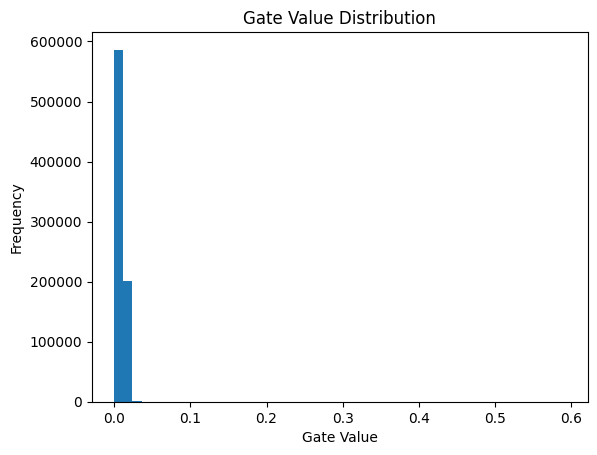

In [55]:
import matplotlib.pyplot as plt

all_gates = []

for module in model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
        all_gates.extend(gates.flatten())

plt.hist(all_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()

L1 regularization adds a penalty proportional to the sum of gate values.
This encourages the model to reduce unnecessary gates to zero,
effectively pruning weights during training.

As lambda increases, sparsity increases but accuracy decreases.
This shows the trade-off between model efficiency and performance.